
#  Air-Pollution (PM2.5) Prediction Using Dataset from Benjing City in China

This notebook containes all steps for a detailed analysis based on UCI Beijing Multi-Site Air-Quality.
Steps include:
- Load & combine Beijing Multi-Site Air-Quality Excel files (UCI)
- Handle missing values via linear interpolation (time-aware, per station)
- Encode wind direction (`wd`) to azimuth degrees (16-sector × 22.5°)
- Min–Max normalization
- Compute Pearson correlation among features and stations
- Build supervised sequences for 1‑step‑ahead prediction of PM2.5 at Aotizhongxin
- Train CNN–LSTM (as in the paper) with Adam, EarlyStopping
- Report MAE / RMSE / R², and save the features Excel



## Imports

If needed, install:
```
pip install pandas numpy matplotlib scikit-learn tensorflow
```


In [1]:
import os, glob, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam



## Configuration

- Set RAW_FOLDER to the directory containing the UCI Beijing Multi-Site Air-Quality Excel files.
- Outputs are written into outputs/ and data/processed/ next to this notebook.
- Target station for Q1: Aotizhongxin.


In [2]:
BASE = Path(".").resolve()
RAW_FOLDER = BASE / r"C:\Users\Mohammad\Desktop\Air Pollution Prediction\dataset"          # put the UCI Excel files here
PROCESSED_FOLDER = BASE / "data" / "processed"
OUTPUTS = BASE / "outputs" / "models"
PROCESSED_FOLDER.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

TARGET_STATION = "Aotizhongxin"
FEATURES_XLSX = PROCESSED_FOLDER / "Aotizhongxin_features.xlsx"

RAW_FOLDER, PROCESSED_FOLDER, OUTPUTS, FEATURES_XLSX


(WindowsPath('C:/Users/Mohammad/Desktop/Air Pollution Prediction/dataset'),
 WindowsPath('C:/Users/Mohammad/Desktop/Air Pollution Prediction/data/processed'),
 WindowsPath('C:/Users/Mohammad/Desktop/Air Pollution Prediction/outputs/models'),
 WindowsPath('C:/Users/Mohammad/Desktop/Air Pollution Prediction/data/processed/Aotizhongxin_features.xlsx'))


## Utility functions

Why linear interpolation? In hourly pollutant series, linear/spline interpolation is appropriate for small gaps and preserves temporal structure, unlike mean/median imputation which destroys dynamics.

Why encode wind direction? Wind direction (wd) is categorical (16-point compass). We map it to azimuth degrees to capture circular structure (N=0°, E=90°, …) used as a numeric feature.


In [3]:
WIND16 = ["N","NNE","NE","ENE","E","ESE","SE","SSE","S","SSW","SW","WSW","W","WNW","NW","NNW"]

def wd_to_degrees(series: pd.Series) -> pd.Series:
    mapping = {name: i*22.5 for i, name in enumerate(WIND16)}
    return series.map(mapping).astype(float)

def minmax_scale(df: pd.DataFrame, cols, feature_range=(0.0,1.0)) -> pd.DataFrame:
    lo, hi = feature_range
    out = df.copy()
    for c in cols:
        v = df[c].astype(float)
        vmin, vmax = np.nanmin(v), np.nanmax(v)
        if np.isfinite(vmin) and np.isfinite(vmax) and vmax != vmin:
            out[c] = (v - vmin) / (vmax - vmin) * (hi - lo) + lo
        else:
            out[c] = 0.0
    return out

def make_supervised(timeseries: np.ndarray, target: np.ndarray, lookback: int, horizon: int=1):
    Xs, ys = [], []
    for t in range(lookback, len(timeseries) - horizon + 1):
        Xs.append(timeseries[t-lookback:t, :])
        ys.append(target[t + horizon - 1])
    X = np.stack(Xs)
    y = np.array(ys)
    return X, y



## Load & Combine UCI Files

The original UCI files contain columns such as:
['No','year','month','day','hour','PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','wd','WSPM','station']

We will:
1. Read all Excel files in RAW_FOLDER.
2. Build a timestamp column dt.
3. Sort by time and station.


In [4]:
def load_all_excel(folder: Path) -> pd.DataFrame:
    paths = sorted(list(folder.glob("*.csv")))
    if not paths:
        raise FileNotFoundError(f"No Excel files found in {folder}. Please put the UCI files there.")
    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    data["minute"] = 0
    data["dt"] = pd.to_datetime(data[["year","month","day","hour","minute"]])
    data = data.drop(columns=["minute"])
    data = data.sort_values(["dt","station"]).reset_index(drop=True)
    return data

data = load_all_excel(RAW_FOLDER)
data.head(), data["station"].unique()[:5], data.shape


(   No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP  \
 0   1  2013      3    1     0    4.0   4.0   4.0   7.0  300.0  77.0  -0.7   
 1   1  2013      3    1     0    3.0   6.0  13.0   7.0  300.0  85.0  -2.3   
 2   1  2013      3    1     0    4.0   4.0   3.0   NaN  200.0  82.0  -2.3   
 3   1  2013      3    1     0    9.0   9.0   3.0  17.0  300.0  89.0  -0.5   
 4   1  2013      3    1     0    4.0   4.0  14.0  20.0  300.0  69.0  -0.7   
 
      PRES  DEWP  RAIN   wd  WSPM       station         dt  
 0  1023.0 -18.8   0.0  NNW   4.4  Aotizhongxin 2013-03-01  
 1  1020.8 -19.7   0.0    E   0.5     Changping 2013-03-01  
 2  1020.8 -19.7   0.0    E   0.5      Dingling 2013-03-01  
 3  1024.5 -21.4   0.0  NNW   5.7        Dongsi 2013-03-01  
 4  1023.0 -18.8   0.0  NNW   4.4      Guanyuan 2013-03-01  ,
 array(['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan'],
       dtype=object),
 (420768, 19))


## Handle Missing Values & Encode wd

- Linear interpolation per station for numeric columns.
- Convert wd → wd_deg (0..360 step 22.5°), then interpolate numeric gaps if needed.


In [ ]:
def preprocess_all(data: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = ["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM"]
    def _interp(g):
        g = g.sort_values("dt").set_index("dt")  # Set dt as index for time-based interpolation without being set this 
        # led to an ValueError of basically not having time for interpolation. as the interpolate(method="time") requires a datetime index.
        # on columns without setting dt as the index first. This causes pandas to reject the "time" method.
        g[numeric_cols] = g[numeric_cols].interpolate(method="time", limit_direction="both", axis=0)
        g["wd_deg"] = wd_to_degrees(g["wd"])
        g["wd_deg"] = g["wd_deg"].interpolate(method="nearest", limit_direction="both")
        return g.reset_index()  # Reset index to return dt as column for consistency
    return data.groupby("station", group_keys=False).apply(_interp)

data_prep = preprocess_all(data)
data_prep.isna().mean().round(4).to_dict()


C:\Users\Mohammad\AppData\Local\Temp\ipykernel_11800\445609397.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return data.groupby("station", group_keys=False).apply(_interp)


{'dt': 0.0,
 'No': 0.0,
 'year': 0.0,
 'month': 0.0,
 'day': 0.0,
 'hour': 0.0,
 'PM2.5': 0.0,
 'PM10': 0.0,
 'SO2': 0.0,
 'NO2': 0.0,
 'CO': 0.0,
 'O3': 0.0,
 'TEMP': 0.0,
 'PRES': 0.0,
 'DEWP': 0.0,
 'RAIN': 0.0,
 'wd': 0.0043,
 'WSPM': 0.0,
 'station': 0.0,
 'wd_deg': 0.0}

=== DATA QUALITY ANALYSIS ===
Total records: 420,768
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Number of stations: 12
Stations: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

=== MISSING DATA PERCENTAGES ===
wd: 0.43%


C:\Users\Mohammad\AppData\Local\Temp\ipykernel_11800\3902539979.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_station = data_prep.groupby('station').apply(lambda x: x.isna().mean())
C:\Users\Mohammad\AppData\Local\Temp\ipykernel_11800\3902539979.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completeness = data_prep.groupby('station').apply(lambda x: (1 - x.isna().mean()).mean())


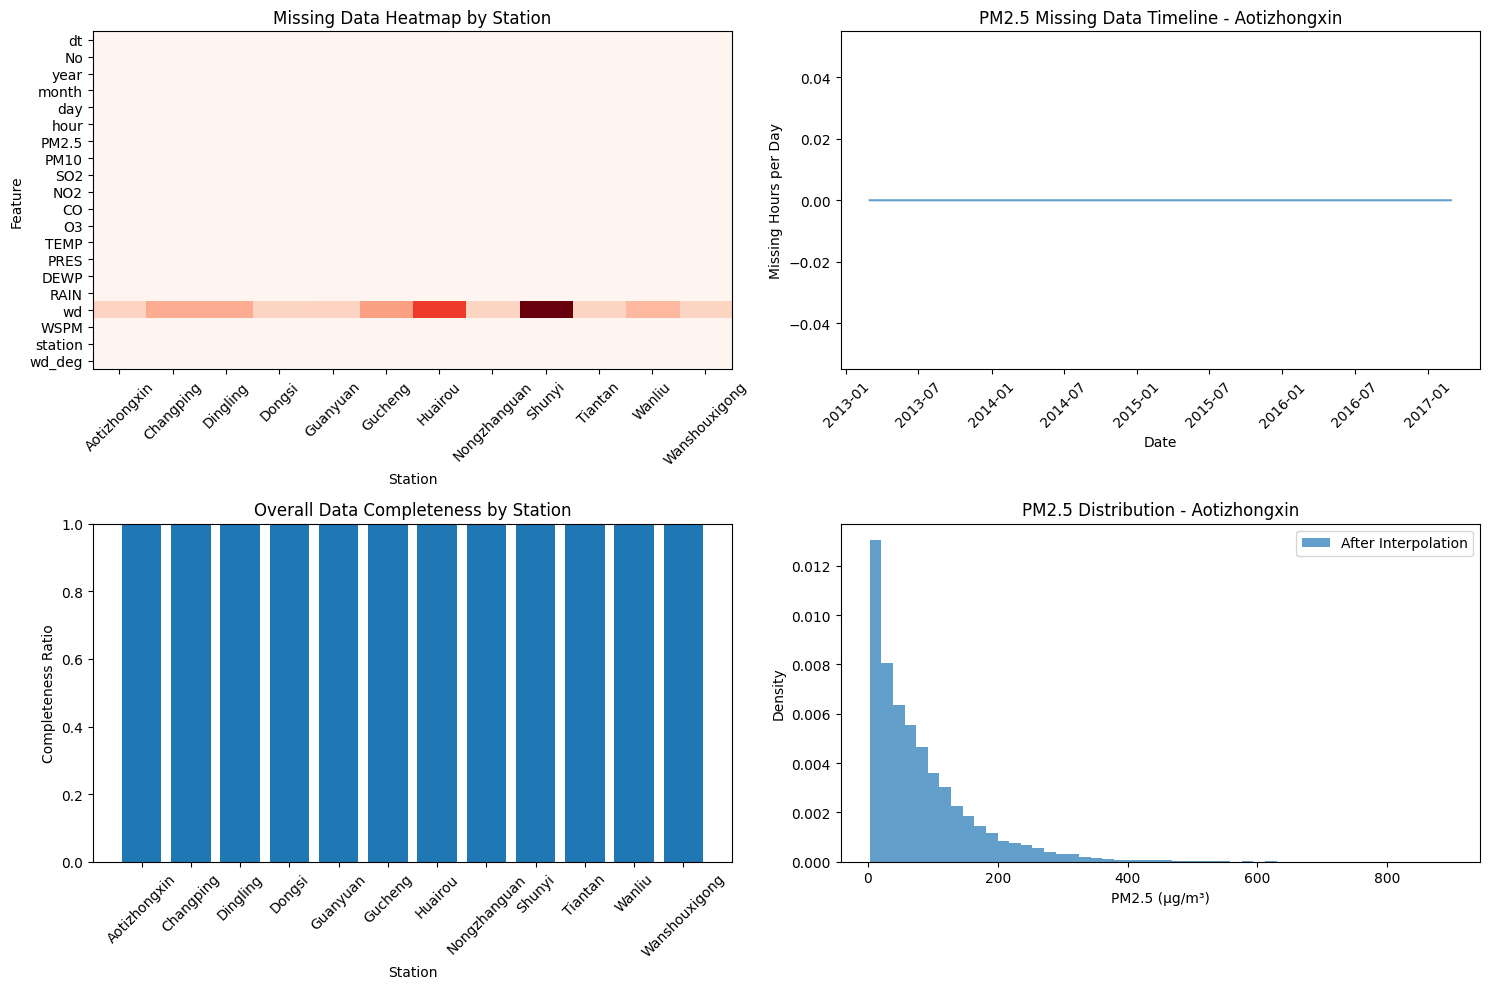


=== STATISTICAL SUMMARY ===
PM2.5 at Aotizhongxin:
  Mean: 82.54 μg/m³
  Median: 58.00 μg/m³
  Std: 81.96 μg/m³
  Min: 3.00 μg/m³
  Max: 898.00 μg/m³

=== DATA QUALITY INSIGHTS ===
Records with any missing data: 1,822 (0.4%)
Maximum consecutive missing hours for PM2.5: 0
Interpolation reduced missing data by: 97.5%


{'dt': 0.0,
 'No': 0.0,
 'year': 0.0,
 'month': 0.0,
 'day': 0.0,
 'hour': 0.0,
 'PM2.5': 0.0,
 'PM10': 0.0,
 'SO2': 0.0,
 'NO2': 0.0,
 'CO': 0.0,
 'O3': 0.0,
 'TEMP': 0.0,
 'PRES': 0.0,
 'DEWP': 0.0,
 'RAIN': 0.0,
 'wd': 0.0043,
 'WSPM': 0.0,
 'station': 0.0,
 'wd_deg': 0.0}

Data analysis with Visualizations

=== DATA QUALITY ANALYSIS ===
Total records: 420,768
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Number of stations: 12
Stations: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

=== MISSING DATA PERCENTAGES ===
wd: 0.43%


C:\Users\Mohammad\AppData\Local\Temp\ipykernel_11800\2424519935.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_station = data_prep.groupby('station').apply(lambda x: x.isna().mean())
C:\Users\Mohammad\AppData\Local\Temp\ipykernel_11800\2424519935.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completeness = data_prep.groupby('station').apply(lambda x: (1 - x.isna().mean()).mean())


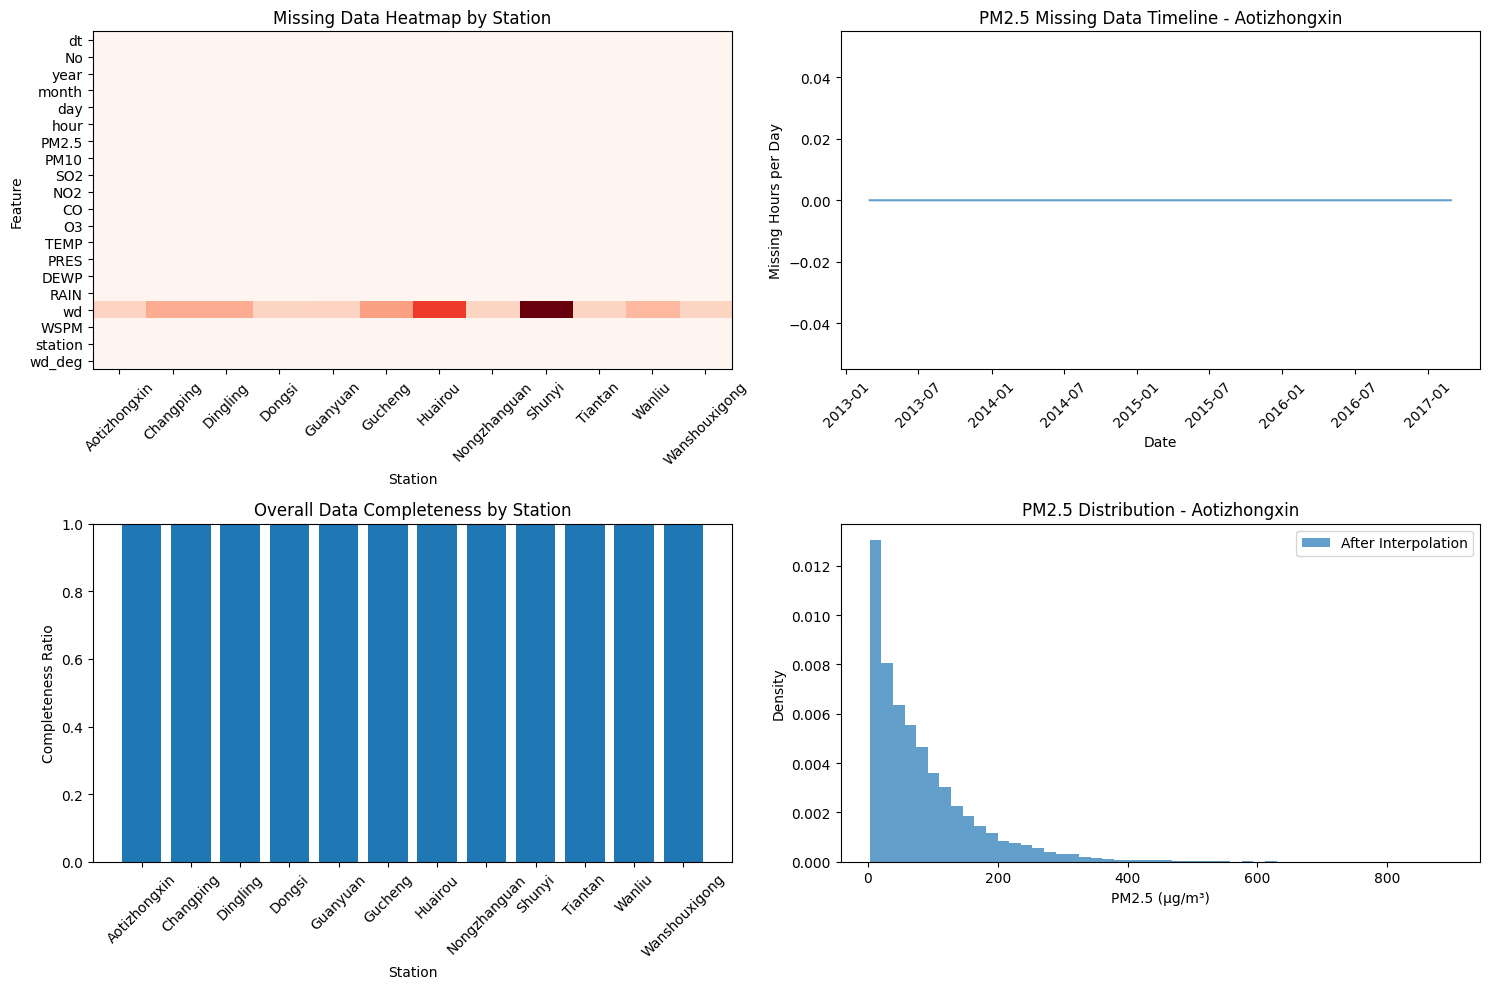


=== STATISTICAL SUMMARY ===
PM2.5 at Aotizhongxin:
  Mean: 82.54 μg/m³
  Median: 58.00 μg/m³
  Std: 81.96 μg/m³
  Min: 3.00 μg/m³
  Max: 898.00 μg/m³

=== DATA QUALITY INSIGHTS ===
Records with any missing data: 1,822 (0.4%)
Maximum consecutive missing hours for PM2.5: 0
Interpolation reduced missing data by: 97.5%


{'dt': 0.0,
 'No': 0.0,
 'year': 0.0,
 'month': 0.0,
 'day': 0.0,
 'hour': 0.0,
 'PM2.5': 0.0,
 'PM10': 0.0,
 'SO2': 0.0,
 'NO2': 0.0,
 'CO': 0.0,
 'O3': 0.0,
 'TEMP': 0.0,
 'PRES': 0.0,
 'DEWP': 0.0,
 'RAIN': 0.0,
 'wd': 0.0043,
 'WSPM': 0.0,
 'station': 0.0,
 'wd_deg': 0.0}

In [11]:
print("=== DATA QUALITY ANALYSIS ===")
print(f"Total records: {len(data_prep):,}")
print(f"Date range: {data_prep['dt'].min()} to {data_prep['dt'].max()}")
print(f"Number of stations: {data_prep['station'].nunique()}")
print(f"Stations: {sorted(data_prep['station'].unique())}")

# Missing data analysis
missing_data = data_prep.isna().mean().round(4)
print("\n=== MISSING DATA PERCENTAGES ===")
for col, missing_pct in missing_data.items():
    if missing_pct > 0:
        print(f"{col}: {missing_pct:.2%}")

# Visualize missing data patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Missing data heatmap by station
missing_by_station = data_prep.groupby('station').apply(lambda x: x.isna().mean())
axes[0,0].imshow(missing_by_station.T, aspect='auto', cmap='Reds')
axes[0,0].set_title('Missing Data Heatmap by Station')
axes[0,0].set_xlabel('Station')
axes[0,0].set_ylabel('Feature')
axes[0,0].set_xticks(range(len(missing_by_station.index)))
axes[0,0].set_xticklabels(missing_by_station.index, rotation=45)
axes[0,0].set_yticks(range(len(missing_by_station.columns)))
axes[0,0].set_yticklabels(missing_by_station.columns)

# 2. Missing data timeline for PM2.5
pm25_missing = data_prep[data_prep['station'] == TARGET_STATION].set_index('dt')['PM2.5'].isna()
pm25_missing_resampled = pm25_missing.resample('D').sum()  # Daily missing count
axes[0,1].plot(pm25_missing_resampled.index, pm25_missing_resampled.values, alpha=0.7)
axes[0,1].set_title(f'PM2.5 Missing Data Timeline - {TARGET_STATION}')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Missing Hours per Day')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Data completeness by station
completeness = data_prep.groupby('station').apply(lambda x: (1 - x.isna().mean()).mean())
axes[1,0].bar(range(len(completeness)), completeness.values)
axes[1,0].set_title('Overall Data Completeness by Station')
axes[1,0].set_xlabel('Station')
axes[1,0].set_ylabel('Completeness Ratio')
axes[1,0].set_xticks(range(len(completeness.index)))
axes[1,0].set_xticklabels(completeness.index, rotation=45)
axes[1,0].set_ylim(0, 1)

# 4. PM2.5 distribution comparison (before/after interpolation)
target_data = data_prep[data_prep['station'] == TARGET_STATION]['PM2.5']
axes[1,1].hist(target_data.dropna(), bins=50, alpha=0.7, label='After Interpolation', density=True)
axes[1,1].set_title(f'PM2.5 Distribution - {TARGET_STATION}')
axes[1,1].set_xlabel('PM2.5 (μg/m³)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Statistical summary
print("\n=== STATISTICAL SUMMARY ===")
print(f"PM2.5 at {TARGET_STATION}:")
target_pm25 = data_prep[data_prep['station'] == TARGET_STATION]['PM2.5']
print(f"  Mean: {target_pm25.mean():.2f} μg/m³")
print(f"  Median: {target_pm25.median():.2f} μg/m³")
print(f"  Std: {target_pm25.std():.2f} μg/m³")
print(f"  Min: {target_pm25.min():.2f} μg/m³")
print(f"  Max: {target_pm25.max():.2f} μg/m³")

# Data quality insights
print("\n=== DATA QUALITY INSIGHTS ===")
total_records = len(data_prep)
missing_records = data_prep.isna().any(axis=1).sum()
print(f"Records with any missing data: {missing_records:,} ({missing_records/total_records:.1%})")

# Check for consecutive missing data patterns
target_station_data = data_prep[data_prep['station'] == TARGET_STATION].sort_values('dt')
consecutive_missing = target_station_data['PM2.5'].isna().groupby((~target_station_data['PM2.5'].isna()).cumsum()).sum()
max_consecutive = consecutive_missing.max()
print(f"Maximum consecutive missing hours for PM2.5: {max_consecutive}")

# Interpolation effectiveness
original_missing = data.isna().sum().sum()
after_interpolation_missing = data_prep.isna().sum().sum()
interpolation_reduction = (original_missing - after_interpolation_missing) / original_missing
print(f"Interpolation reduced missing data by: {interpolation_reduction:.1%}")

missing_data.to_dict()



## Correlation Checks

We compute Pearson correlations to verify:
- Spatial coupling between PM2.5 at Aotizhongxin and other stations.
- Feature relationships (e.g., PM2.5 vs PM10/CO, meteorology).

You can optionally visualize matrices; we keep one plot per figure and default styles.


Top 5 stations most correlated with Aotizhongxin (PM2.5):
station
Aotizhongxin    1.000000
Guanyuan        0.953684
Dongsi          0.949480
Nongzhanguan    0.942509
Wanliu          0.938450
Tiantan         0.930921
Name: Aotizhongxin, dtype: float64


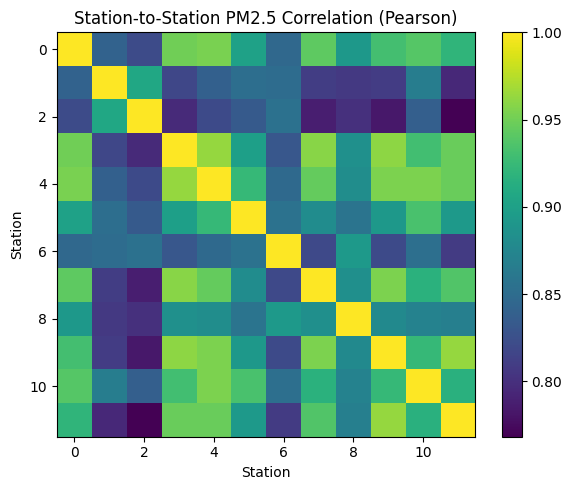

In [7]:

pm25_pivot = data_prep.pivot(index="dt", columns="station", values="PM2.5")
spatial_corr = pm25_pivot.corr(method="pearson")
print("Top 5 stations most correlated with Aotizhongxin (PM2.5):")
print(spatial_corr[TARGET_STATION].sort_values(ascending=False).head(6))

plt.figure(figsize=(6,5))
plt.imshow(spatial_corr, aspect="auto")
plt.title("Station-to-Station PM2.5 Correlation (Pearson)")
plt.xlabel("Station")
plt.ylabel("Station")
plt.colorbar()
plt.tight_layout()
plt.show()


In [8]:

feat_cols = ["PM2.5","PM10","CO","TEMP","PRES","DEWP","RAIN","wd_deg","WSPM"]
feat_df = data_prep[data_prep["station"]==TARGET_STATION][["dt"] + feat_cols].set_index("dt")
feat_corr = feat_df.corr(method="pearson")
feat_corr.round(3)


,PM2.5,PM10,CO,TEMP,PRES,DEWP,RAIN,wd_deg,WSPM
PM2.5,1.000,0.875,0.786,-0.123,-0.009,0.123,-0.014,-0.136,-0.276
PM10,0.875,1.000,0.682,-0.109,-0.035,0.061,-0.028,-0.082,-0.180
CO,0.786,0.682,1.000,-0.359,0.207,-0.097,-0.016,-0.179,-0.276
TEMP,-0.123,-0.109,-0.359,1.000,-0.827,0.823,0.037,0.094,0.038
PRES,-0.009,-0.035,0.207,-0.827,1.000,-0.776,-0.060,-0.050,0.071
DEWP,0.123,0.061,-0.097,0.823,-0.776,1.000,0.081,-0.072,-0.305
RAIN,-0.014,-0.028,-0.016,0.037,-0.060,0.081,1.000,-0.017,0.022
wd_deg,-0.136,-0.082,-0.179,0.094,-0.050,-0.072,-0.017,1.000,0.253
WSPM,-0.276,-0.180,-0.276,0.038,0.071,-0.305,0.022,0.253,1.000


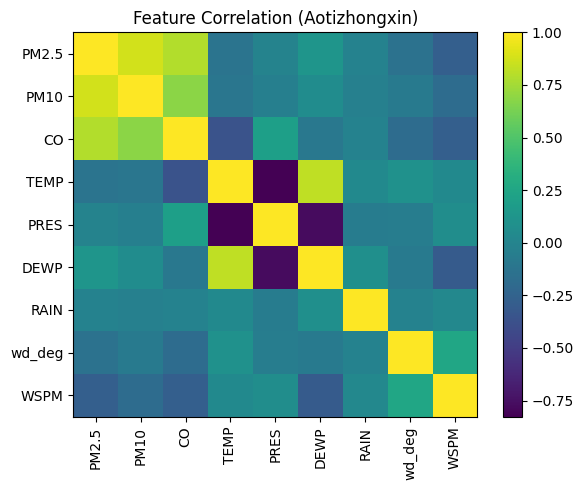

In [9]:

plt.figure(figsize=(6,5))
plt.imshow(feat_corr.values, aspect="auto")
plt.title("Feature Correlation (Aotizhongxin)")
plt.xticks(ticks=range(len(feat_corr.columns)), labels=feat_corr.columns, rotation=90)
plt.yticks(ticks=range(len(feat_corr.index)), labels=feat_corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()



## Save features for Aotizhongxin (Excel)

We assemble a single table containing:
- Target station columns: PM2.5, PM10, CO, TEMP, PRES, DEWP, RAIN, wd_deg, WSPM
- PM2.5 of all 12 stations as spatial features (PM2.5_{station})
- Timestamp dt

This file is basically the deliverable for the feature-prep step.


In [12]:

pivot_pm25 = data_prep.pivot(index="dt", columns="station", values="PM2.5")
pivot_pm25.columns = [f"PM2.5_{c}" for c in pivot_pm25.columns]

base_cols = ["dt","PM2.5","PM10","CO","TEMP","PRES","DEWP","RAIN","wd_deg","WSPM"]
base = data_prep[data_prep["station"]==TARGET_STATION][base_cols].copy()
features_df = base.merge(pivot_pm25, left_on="dt", right_index=True, how="left").sort_values("dt").reset_index(drop=True)

features_df.to_excel(FEATURES_XLSX, index=False)
FEATURES_XLSX, features_df.shape, features_df.head(3)


(WindowsPath('C:/Users/Mohammad/Desktop/Air Pollution Prediction/data/processed/Aotizhongxin_features.xlsx'),
 (35064, 22),
                    dt  PM2.5  PM10     CO  TEMP    PRES  DEWP  RAIN  wd_deg  \
 0 2013-03-01 00:00:00    4.0   4.0  300.0  -0.7  1023.0 -18.8   0.0   337.5   
 1 2013-03-01 01:00:00    8.0   8.0  300.0  -1.1  1023.2 -18.2   0.0     0.0   
 2 2013-03-01 02:00:00    7.0   7.0  300.0  -1.1  1023.5 -18.2   0.0   337.5   
 
    WSPM  ...  PM2.5_Dingling  PM2.5_Dongsi  PM2.5_Guanyuan  PM2.5_Gucheng  \
 0   4.4  ...             4.0           9.0             4.0            6.0   
 1   4.7  ...             7.0           4.0             4.0            6.0   
 2   5.6  ...             5.0           7.0             3.0            5.0   
 
    PM2.5_Huairou  PM2.5_Nongzhanguan  PM2.5_Shunyi  PM2.5_Tiantan  \
 0            7.0                 5.0           3.0            6.0   
 1            4.0                 8.0          12.0            6.0   
 2            4.0             


## Build the Supervised Dataset

We normalize to [0,1], create sliding windows of past L hours to predict next hour PM2.5 at Aotizhongxin.
We keep a chronological 80%/20% train/test split as in the paper.


In [ ]:
num_cols = [c for c in features_df.columns if c != "dt"]
scaled = features_df.copy()
scaled[num_cols] = (scaled[num_cols] - scaled[num_cols].min())/(scaled[num_cols].max()-scaled[num_cols].min())

target = scaled["PM2.5"].values.astype(float)
X_all = scaled[num_cols].values.astype(float)

def make_split(lookback):
    X_seq, y = make_supervised(X_all, target, lookback=lookback, horizon=1)
    n = len(X_seq)
    n_train = int(n * 0.8)
    X_tr, y_tr = X_seq[:n_train], y[:n_train]
    X_te, y_te = X_seq[n_train:], y[n_train:]
    return X_tr, y_tr, X_te, y_te

for L in (24, 168):
    X_tr, y_tr, X_te, y_te = make_split(L)
    print(f"Lookback={L:>3}h -> Train {X_tr.shape}, Test {X_te.shape}")


Lookback= 24h -> Train (28032, 24, 21), Test (7008, 24, 21)
Lookback=168h -> Train (27916, 168, 21), Test (6980, 168, 21)



## CNN–LSTM Model & Training

Architecture (per paper):
- Conv1D(64) → BN → Conv1D(64) → BN → Conv1D(32) → MaxPool(3)
- LSTM(100, return_sequences) → Dropout(0.1) → LSTM(50) → Dropout(0.1) → Dense(1)
- Optimizer: Adam (lr=1e-3, decay=1e-4), Loss: MSE
- EarlyStopping: min_delta=1e-3, patience=50

You can run two experiments:
- lookback=24 (1 day)
- lookback=168 (7 days)

Note: Training may take time depending on hardware; you can reduce epochs for a quick run.


In [17]:

def build_cnn_lstm(n_features: int):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, padding="causal", activation="relu", input_shape=(None, n_features)))
    model.add(BatchNormalization())
    model.add(Conv1D(filters=64, kernel_size=3, padding="causal", activation="relu"))
    model.add(BatchNormalization())
    model.add(Conv1D(filters=32, kernel_size=3, padding="causal", activation="relu"))
    model.add(MaxPooling1D(pool_size=3))
    model.add(LSTM(100, return_sequences=True))
    model.add(Dropout(0.1))
    model.add(LSTM(50))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=1e-3, decay=1e-4), loss="mse")
    return model

def train_and_eval(lookback=24, batch_size=32, epochs=200, patience=50):
    X_tr, y_tr, X_te, y_te = make_split(lookback)
    model = build_cnn_lstm(n_features=X_tr.shape[-1])
    ckpt_path = OUTPUTS / f"cnn_lstm_lb{lookback}_bs{batch_size}.keras"
    ckpt = ModelCheckpoint(str(ckpt_path), save_best_only=True, monitor="val_loss")
    es = EarlyStopping(monitor="val_loss", min_delta=1e-3, patience=patience, restore_best_weights=True)
    hist = model.fit(X_tr, y_tr, validation_split=0.1, epochs=epochs, batch_size=batch_size, callbacks=[ckpt, es], verbose=2)
    pred = model.predict(X_te).ravel()
    mae = mean_absolute_error(y_te, pred)
    rmse = mean_squared_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    metrics = {"lookback": lookback, "batch_size": batch_size, "MAE": float(mae), "RMSE": float(rmse), "R2": float(r2)}
    with open(OUTPUTS / f"metrics_lb{lookback}_bs{batch_size}.json", "w") as f:
        json.dump(metrics, f, indent=2)
    print(metrics)
    return model, metrics, (y_te, pred)


In [19]:
model24, m24, (y_te24, p24) = train_and_eval(lookback=24, batch_size=32, epochs=50, patience=10)

Epoch 1/50


C:\Users\Mohammad\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Mohammad\AppData\Roaming\Python\Python313\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


789/789 - 13s - 17ms/step - loss: 0.0027 - val_loss: 0.0010
Epoch 2/50
789/789 - 9s - 11ms/step - loss: 0.0011 - val_loss: 9.8294e-04
Epoch 3/50
789/789 - 9s - 11ms/step - loss: 8.0890e-04 - val_loss: 7.1683e-04
Epoch 4/50
789/789 - 9s - 12ms/step - loss: 7.1184e-04 - val_loss: 9.0375e-04
Epoch 5/50
789/789 - 9s - 12ms/step - loss: 6.5011e-04 - val_loss: 7.0826e-04
Epoch 6/50
789/789 - 9s - 11ms/step - loss: 5.9517e-04 - val_loss: 7.3285e-04
Epoch 7/50
789/789 - 8s - 10ms/step - loss: 5.7580e-04 - val_loss: 7.7032e-04
Epoch 8/50
789/789 - 8s - 11ms/step - loss: 5.5249e-04 - val_loss: 6.4920e-04
Epoch 9/50
789/789 - 9s - 11ms/step - loss: 5.6235e-04 - val_loss: 7.8262e-04
Epoch 10/50
789/789 - 8s - 10ms/step - loss: 5.4542e-04 - val_loss: 5.6056e-04
Epoch 11/50
789/789 - 8s - 11ms/step - loss: 5.2529e-04 - val_loss: 7.1345e-04
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
{'lookback': 24, 'batch_size': 32, 'MAE': 0.017383689306692696, 'RMSE': 0.0007418290959273585, 'R2': 0.9150072753223327}


In [20]:
model168, m168, (y_te168, p168) = train_and_eval(lookback=168, batch_size=32, epochs=50, patience=10)

C:\Users\Mohammad\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Mohammad\AppData\Roaming\Python\Python313\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/50
786/786 - 40s - 51ms/step - loss: 0.0033 - val_loss: 0.0015
Epoch 2/50
786/786 - 34s - 44ms/step - loss: 9.8622e-04 - val_loss: 9.8998e-04
Epoch 3/50
786/786 - 35s - 45ms/step - loss: 8.3058e-04 - val_loss: 7.3859e-04
Epoch 4/50
786/786 - 34s - 44ms/step - loss: 6.8618e-04 - val_loss: 6.9490e-04
Epoch 5/50
786/786 - 35s - 44ms/step - loss: 6.6483e-04 - val_loss: 0.0012
Epoch 6/50
786/786 - 34s - 44ms/step - loss: 6.0316e-04 - val_loss: 5.7547e-04
Epoch 7/50
786/786 - 34s - 44ms/step - loss: 5.9002e-04 - val_loss: 0.0015
Epoch 8/50
786/786 - 34s - 43ms/step - loss: 6.8035e-04 - val_loss: 5.7623e-04
Epoch 9/50
786/786 - 31s - 40ms/step - loss: 5.4988e-04 - val_loss: 7.1171e-04
Epoch 10/50
786/786 - 32s - 41ms/step - loss: 5.3035e-04 - val_loss: 7.6018e-04
Epoch 11/50
786/786 - 31s - 40ms/step - loss: 5.2083e-04 - val_loss: 6.1158e-04
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
{'lookback': 168, 'batch_size': 32, 'MAE': 0.019340358957248057, 'RMSE': 0.0008326640390654473, 'R2': 0


## Visualize Predictions (Optional)

Plot a short window of prediction vs ground truth for qualitative inspection.


In [23]:
def plot_pred_vs_truth(y_true, y_pred, start=0, window=300, title="Prediction vs Truth (normalized)", save_figure=True):
    """
    Plot prediction vs truth comparison and optionally save the figure.
    
    Parameters:
    - y_true: Ground truth values
    - y_pred: Predicted values
    - start: Starting index for the plot window
    - window: Number of points to plot
    - title: Title for the plot (also used as filename if saving)
    - save_figure: Whether to save the figure to file
    """
    end = min(start+window, len(y_true))
    plt.figure(figsize=(12, 4))
    plt.plot(range(start, end), y_true[start:end], label="Truth", alpha=0.8, linewidth=1.5)
    plt.plot(range(start, end), y_pred[start:end], label="Prediction", alpha=0.8, linewidth=1.5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Time index (test set)", fontsize=12)
    plt.ylabel("PM2.5 (normalized)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the figure if requested
    if save_figure:
        # Create a safe filename from the title
        safe_filename = "".join(c for c in title if c.isalnum() or c in (' ', '-', '_')).rstrip()
        safe_filename = safe_filename.replace(' ', '_') + '.png'
        
        # Save to outputs directory
        save_path = OUTPUTS / safe_filename
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Figure saved as: {save_path}")
    
    plt.show()

✅ Figure saved as: C:\Users\Mohammad\Desktop\Air Pollution Prediction\outputs\models\Lag1-Day.png


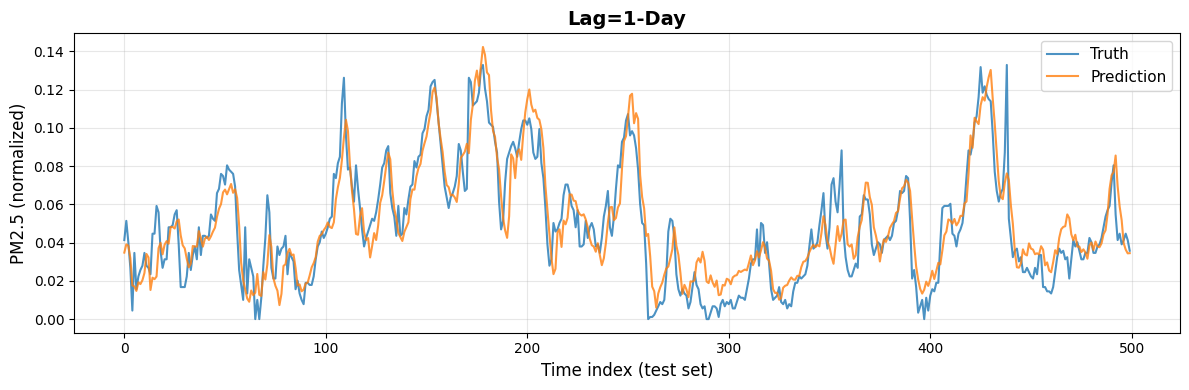

In [24]:
plot_pred_vs_truth(y_te24, p24, start=0, window=500, title="Lag=1-Day")

✅ Figure saved as: C:\Users\Mohammad\Desktop\Air Pollution Prediction\outputs\models\Lag7-Day.png


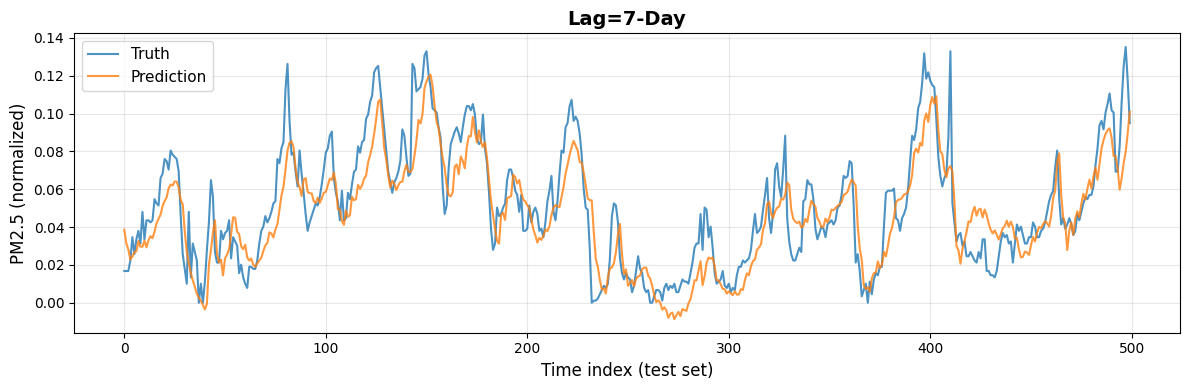

In [25]:
plot_pred_vs_truth(y_te168, p168, start=0, window=500, title="Lag=7-Day")


## Notes & Expected Results

- Paper reports (batch size 32):
  - Lag=1 day (24h): MAE ≈ 6.74, RMSE ≈ 12.92, R² ≈ 0.989
  - Lag=7 days (168h): MAE ≈ 9.03, RMSE ≈ 16.63, R² ≈ 0.979
Small deviations can occur due to random initialization and environment differences.
